In [392]:
!pip install seaborn

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [393]:
import seaborn as sns

In [394]:
import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1.Import Libraries

In [395]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.style.use('default')

## 2. Load Dataset

In [396]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Dataset Information

In [397]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


## 4. Statistical Summary

In [398]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 5. Check Missing Values

In [399]:
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


## 6. Histograms

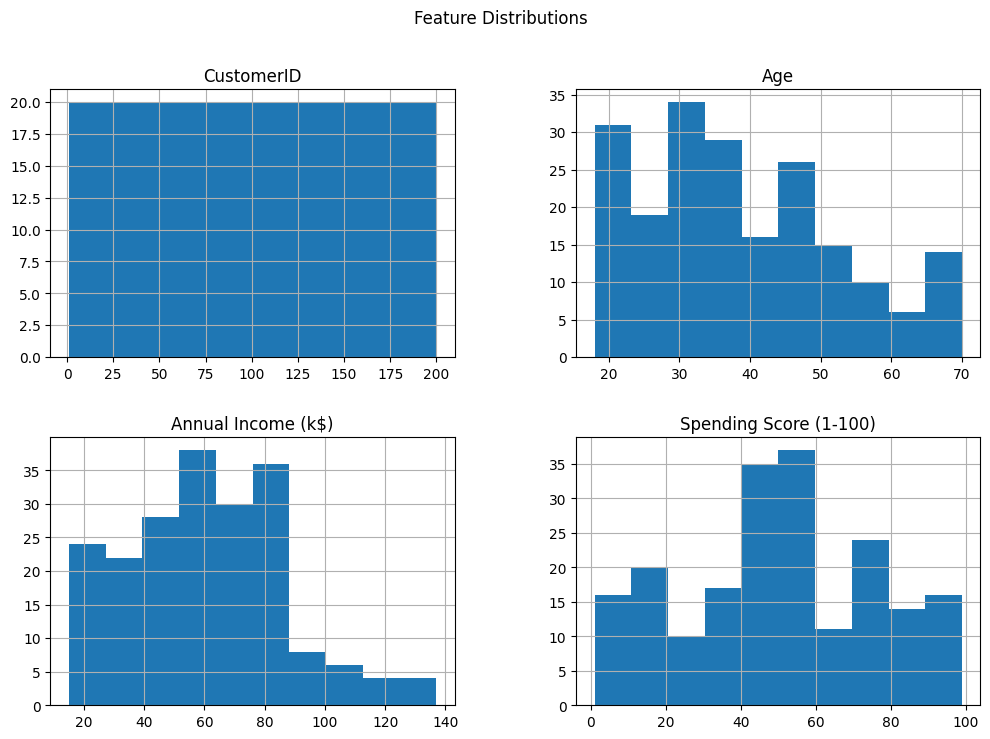

In [400]:
df.hist(figsize=(12, 8))

plt.suptitle("Feature Distributions")

plt.show()

## 7. Outlier Detection

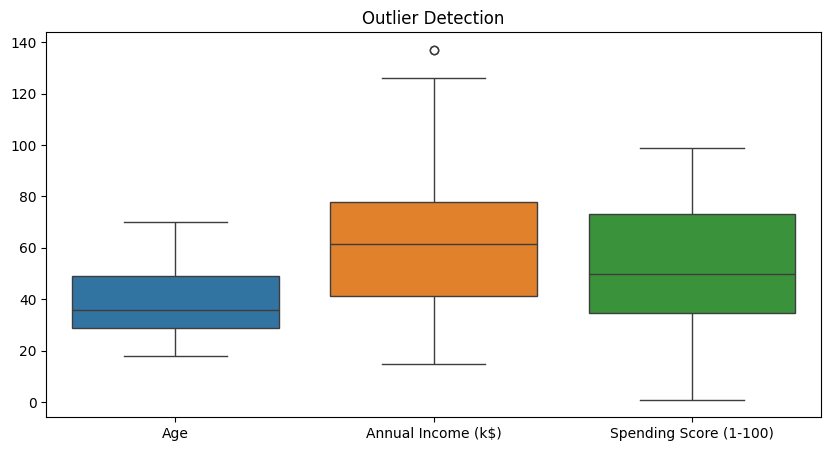

In [401]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df[
        ['Age',
         'Annual Income (k$)',
         'Spending Score (1-100)']
    ]
)

plt.title("Outlier Detection")

plt.show()

## 8. Gender Distribution

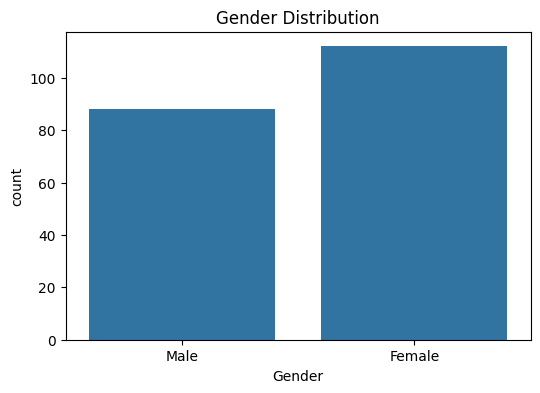

In [402]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    data=df
)

plt.title("Gender Distribution")

plt.show()

## 9. Correlation Matrix

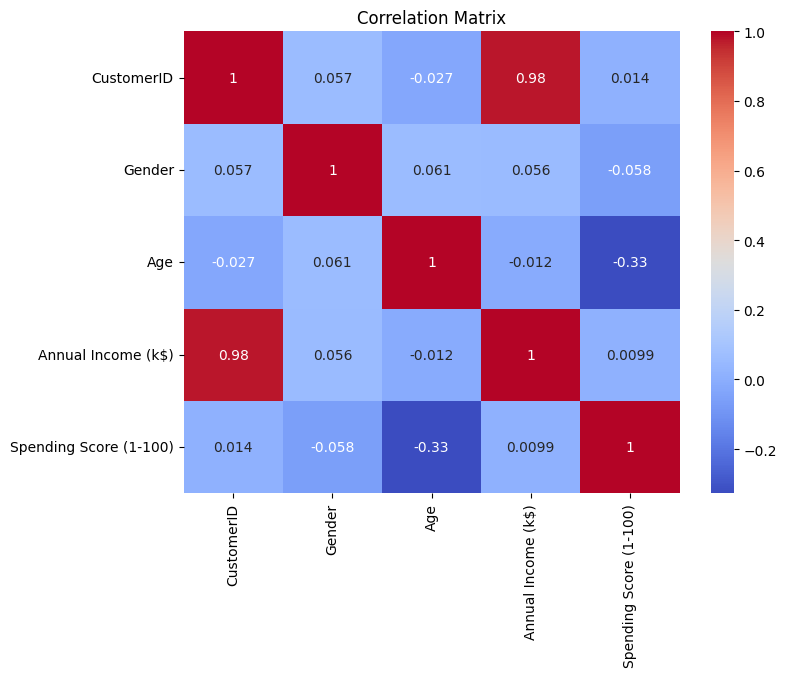

In [403]:
df_corr = df.copy()

encoder = LabelEncoder()

df_corr['Gender'] = encoder.fit_transform(
    df_corr['Gender']
)

corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

## 10. Scatter Plot

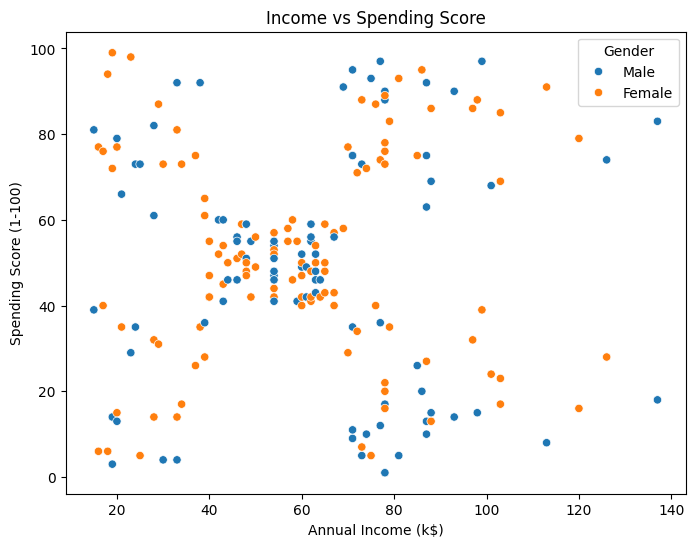

In [404]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Gender',
    data=df
)

plt.title("Income vs Spending Score")

plt.show()

## 11. Remove CustomerID

In [405]:
df_model = df.drop(
    'CustomerID',
    axis=1
)

## 12. Encode Gender

In [406]:
encoder = LabelEncoder()

df_model['Gender'] = encoder.fit_transform(
    df_model['Gender']
)

df_model.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


## 13. Feature Selection

In [407]:
X = df_model[
    ['Age',
     'Annual Income (k$)',
     'Spending Score (1-100)']
]

## 14. Feature Scaling

In [408]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(200, 3)


## 15. Elbow Method

In [409]:
wcss = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

    print(
        f"K = {k}, WCSS = {model.inertia_:.2f}"
    )

K = 1, WCSS = 600.00
K = 2, WCSS = 389.39
K = 3, WCSS = 295.21
K = 4, WCSS = 205.23
K = 5, WCSS = 168.25
K = 6, WCSS = 133.87
K = 7, WCSS = 117.01
K = 8, WCSS = 103.87
K = 9, WCSS = 93.09
K = 10, WCSS = 82.39


## 16. Elbow Curve

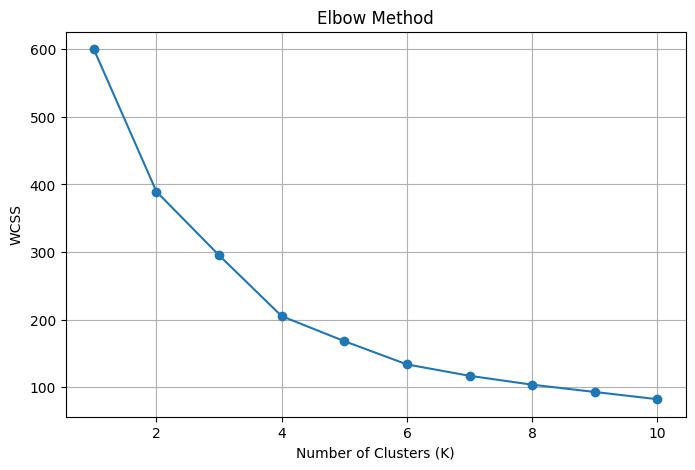

In [410]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

## 17. Silhouette Scores

In [411]:
scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

    print(
        f"K = {k}, Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.3355
K = 3, Silhouette Score = 0.3578
K = 4, Silhouette Score = 0.4040
K = 5, Silhouette Score = 0.4166
K = 6, Silhouette Score = 0.4284
K = 7, Silhouette Score = 0.4172
K = 8, Silhouette Score = 0.4082
K = 9, Silhouette Score = 0.4177
K = 10, Silhouette Score = 0.4066


## 18. Silhouette Plot

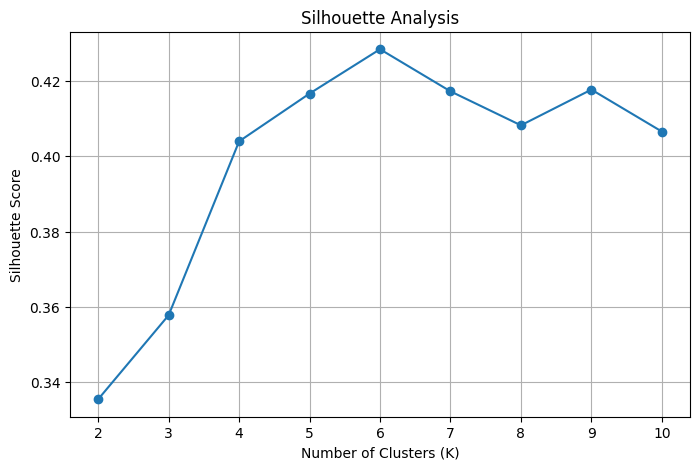

In [412]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

## 19. Final K-Means Model

In [413]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

## 20. Final Evaluation

In [414]:
final_score = silhouette_score(
    X_scaled,
    clusters
)

print(
    "Final Silhouette Score:",
    round(final_score, 4)
)

Final Silhouette Score: 0.4166


## 21. Cluster Statistics

In [415]:
cluster_summary = df.groupby('Cluster')[
    ['Age',
     'Annual Income (k$)',
     'Spending Score (1-100)']
].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


## 22. Cluster Visualization

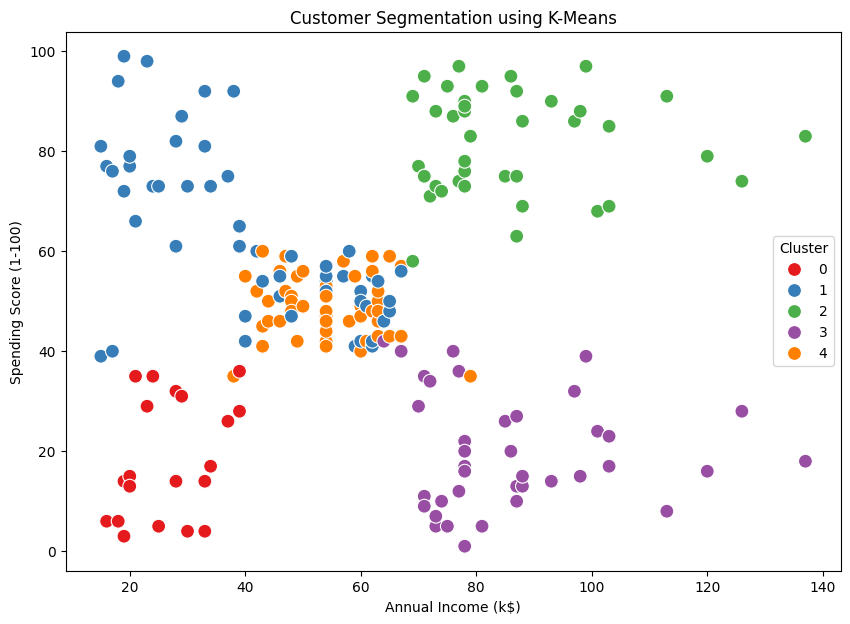

In [416]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.title(
    "Customer Segmentation using K-Means"
)

plt.show()

## 23. Cluster Interpretation

In [417]:
for cluster in sorted(df['Cluster'].unique()):

    print(f"\n===== Cluster {cluster} =====")

    print(
        df[df['Cluster'] == cluster][
            ['Age',
             'Annual Income (k$)',
             'Spending Score (1-100)']
        ].mean()
    )


===== Cluster 0 =====
Age                       46.25
Annual Income (k$)        26.75
Spending Score (1-100)    18.35
dtype: float64

===== Cluster 1 =====
Age                       25.185185
Annual Income (k$)        41.092593
Spending Score (1-100)    62.240741
dtype: float64

===== Cluster 2 =====
Age                       32.875
Annual Income (k$)        86.100
Spending Score (1-100)    81.525
dtype: float64

===== Cluster 3 =====
Age                       39.871795
Annual Income (k$)        86.102564
Spending Score (1-100)    19.358974
dtype: float64

===== Cluster 4 =====
Age                       55.638298
Annual Income (k$)        54.382979
Spending Score (1-100)    48.851064
dtype: float64


## 24. Conclusion

In [418]:
print("""
Customer segmentation was successfully performed using K-Means clustering.

Key findings:
- Missing values and outliers were analyzed.
- Features were standardized before clustering.
- Elbow Method and Silhouette Score were used to determine the optimal number of clusters.
- Customers were grouped according to age, income, and spending behavior.
- The results can support targeted marketing and business strategies.
""")


Customer segmentation was successfully performed using K-Means clustering.

Key findings:
- Missing values and outliers were analyzed.
- Features were standardized before clustering.
- Elbow Method and Silhouette Score were used to determine the optimal number of clusters.
- Customers were grouped according to age, income, and spending behavior.
- The results can support targeted marketing and business strategies.

